# primesense 🎬
## Notebook 02 — Exploratory Data Analysis & Visualization

---

### 🗺️ About This Notebook

Before building any model, a good data scientist spends time **listening to the data**. This notebook is dedicated entirely to that — understanding the patterns, distributions, and stories hidden inside 233,000+ Amazon Prime Video reviews.

EDA serves two purposes here:
1. **Business insights** — What do customers actually feel? Which genres do they love? How has sentiment changed over time?
2. **Modeling intelligence** — What does the class imbalance look like? What words dominate each sentiment class? This directly informs our preprocessing and modeling strategy.

---

### 🎯 What This Notebook Covers

1. Sentiment distribution & class imbalance
2. Sentiment trends over time
3. Review length analysis by sentiment
4. Sentiment by genre (categories)
5. Sentiment by price
6. Word clouds by sentiment
7. Top unigrams, bigrams & trigrams by sentiment
8. POS analysis — top adjectives & adverbs by sentiment

---
## 2.0 Imports & Configuration

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize
import warnings

from src.preprocess import full_preprocess, clean_text, remove_stopwords

nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

with open('../config.yaml', 'r') as f:
    CONFIG = yaml.safe_load(f)

# Consistent colors for the 3 sentiment classes
SENTIMENT_COLORS = {
    'positive': '#2ecc71',
    'neutral' : '#f39c12',
    'negative': '#e74c3c'
}
FIGURES_PATH = '../reports/figures/'
os.makedirs(FIGURES_PATH, exist_ok=True)

print('✅ Libraries loaded.')

✅ Libraries loaded.


---
## 2.1 Load Processed Data

In [3]:
# Full dataset for sentiment/time/text analysis
df = pd.read_csv('../data/processed/reviews_model.csv', parse_dates=['timestamp'])

# Genre subset for category/price analysis
df_genre = pd.read_csv('../data/processed/reviews_genre.csv', parse_dates=['timestamp'])

print(f'Full dataset  : {df.shape[0]:,} rows')
print(f'Genre dataset : {df_genre.shape[0]:,} rows')
df.head(10)

Full dataset  : 233,041 rows
Genre dataset : 33,554 rows


,rating,timestamp,year,month,review_text,reviews,sentiment
0,5,2015-08-24 03:07:17.000,2015,8,"Amazon, please buy the show! I'm hooked!","Five Stars Amazon, please buy the show! I'm h...",positive
1,5,2016-04-19 21:16:50.000,2016,4,My Kiddos LOVE this show!!,Five Stars My Kiddos LOVE this show!!,positive
2,5,2020-05-28 04:13:47.074,2020,5,"...isn't always how you expect it to be, but w...",What Love Is... ...isn't always how you expec...,positive
3,5,2020-04-16 01:15:47.540,2020,4,As you learn about the very unique characters ...,QUIRKY TURNS TO HEARTSTRINGS As you learn abo...,positive
4,5,2019-09-29 05:17:12.700,2019,9,Our family loved the film. We have kids and th...,Way better than the harsh reviews. Our family...,positive
5,5,2018-07-02 18:35:20.803,2018,7,Great movie! My kids are obsessed with HP!,Five Stars Great movie! My kids are obsessed ...,positive
6,5,2017-01-31 13:43:47.000,2017,1,LOVE this movie! Hits you in the feels!,Five Stars LOVE this movie! Hits you in the f...,positive
7,5,2016-10-17 12:44:51.000,2016,10,LOVED Woodlawn & the story behind it!,Five Stars LOVED Woodlawn & the story behind it!,positive
8,5,2015-11-03 19:40:37.000,2015,11,Great Movie!,Five Stars Great Movie!,positive
9,5,2015-10-27 17:57:20.000,2015,10,Great & exciting movie!,Five Stars Great & exciting movie!,positive


---
## 2.2 Sentiment Distribution & Class Imbalance

Understanding class balance is the single most important thing to check before modeling. A heavily imbalanced dataset will produce a model that simply predicts the majority class and still appears accurate.

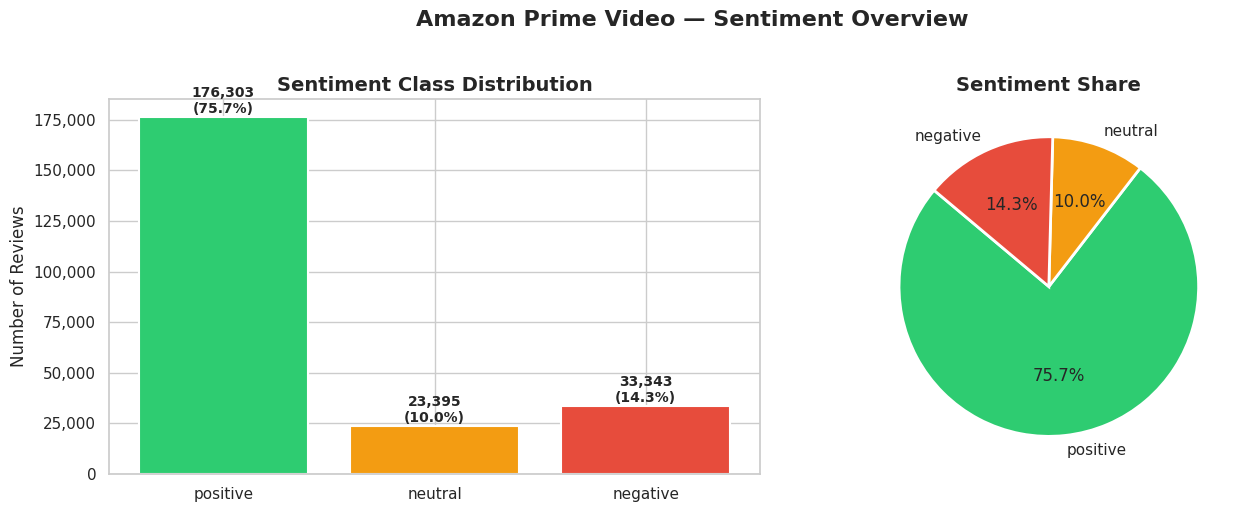

💾 Saved → reports/figures/sentiment_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['positive', 'neutral', 'negative']
colors = [SENTIMENT_COLORS[s] for s in order]
counts = df['sentiment'].value_counts()[order]

# Bar chart
bars = axes[0].bar(order, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Sentiment Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{count:,}\n({count/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=order, colors=colors, autopct='%1.1f%%',
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Sentiment Share', fontsize=14, fontweight='bold')

plt.suptitle('Amazon Prime Video — Sentiment Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → reports/figures/sentiment_distribution.png')

> **Insight:** The dataset is heavily skewed — **positive reviews dominate at ~77%**, while neutral (~11%) and negative (~12%) are minorities. This J-curve distribution is typical of Amazon reviews: satisfied customers are more motivated to leave reviews than ambivalent ones. This class imbalance **will cause models to over-predict positive** — we must address it with undersampling or class weights in Notebook 03.

---
## 2.3 Sentiment Trends Over Time

Has Prime Video's reception improved or declined over the years? Tracking sentiment over time reveals long-term patterns in customer satisfaction.

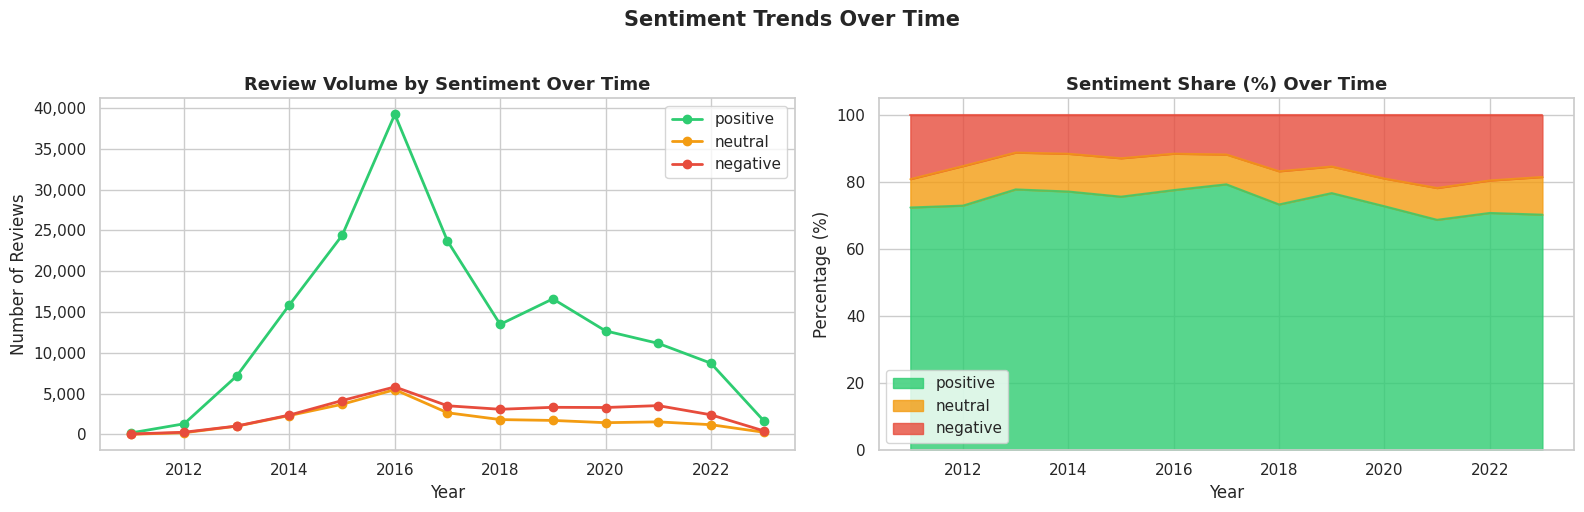

💾 Saved → reports/figures/sentiment_trends_over_time.png


In [5]:
# Group by year and sentiment
time_df = (df.groupby(['year', 'sentiment'])
             .size()
             .reset_index(name='count'))

# Filter to years with meaningful data
year_counts = df['year'].value_counts()
valid_years = year_counts[year_counts > 100].index
time_df = time_df[time_df['year'].isin(valid_years)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Absolute counts
for sentiment in order:
    subset = time_df[time_df['sentiment'] == sentiment]
    axes[0].plot(subset['year'], subset['count'],
                 marker='o', label=sentiment,
                 color=SENTIMENT_COLORS[sentiment], linewidth=2)
axes[0].set_title('Review Volume by Sentiment Over Time', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Reviews')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Percentage share over time
pivot = time_df.pivot(index='year', columns='sentiment', values='count').fillna(0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct[order].plot(kind='area', stacked=True, ax=axes[1],
                      color=colors, alpha=0.8)
axes[1].set_title('Sentiment Share (%) Over Time', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(loc='lower left')

plt.suptitle('Sentiment Trends Over Time', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}sentiment_trends_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → reports/figures/sentiment_trends_over_time.png')

> **Insight:** Review volume grew significantly from 2015 onward as Prime Video expanded its library and global reach. The share of positive sentiment has remained consistently dominant, but watch for any years where negative sentiment spikes — these often correlate with controversial content decisions, pricing changes, or technical outages.

---
## 2.4 Review Length Analysis

Do negative reviewers write more? Do positive ones keep it short? Review length is both an analytical insight and a useful feature signal.

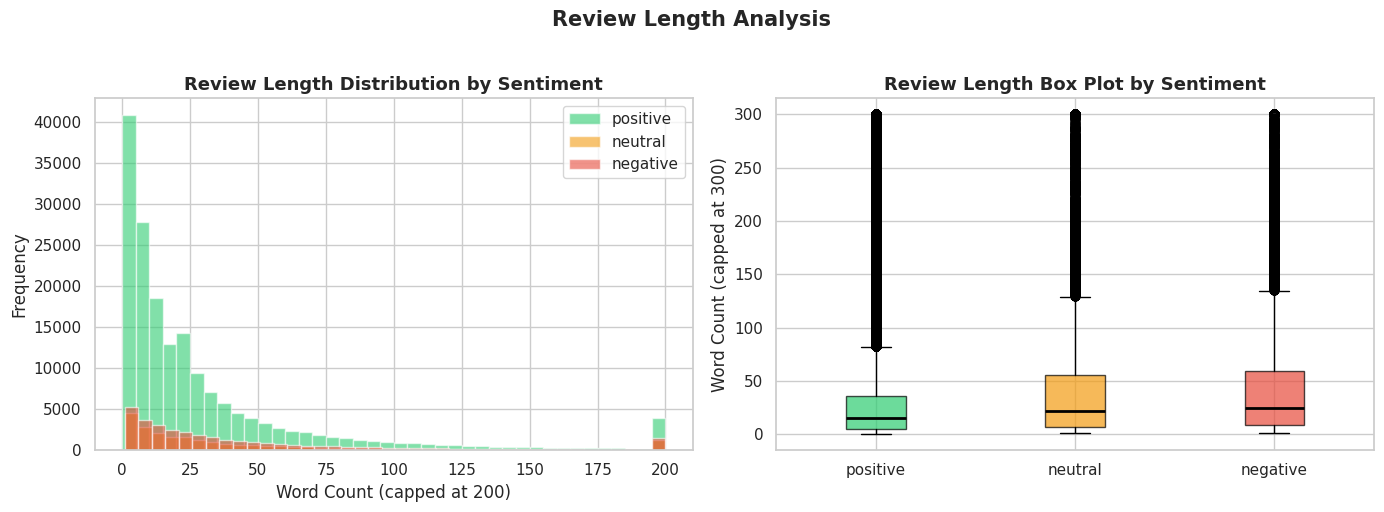


Average Review Length by Sentiment:
  positive  : mean=33 words, median=15 words
  neutral   : mean=53 words, median=22 words
  negative  : mean=51 words, median=25 words


In [6]:
df['review_length'] = df['review_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of review length by sentiment
for sentiment in order:
    subset = df[df['sentiment'] == sentiment]['review_length']
    axes[0].hist(subset.clip(upper=200), bins=40, alpha=0.6,
                 label=sentiment, color=SENTIMENT_COLORS[sentiment])
axes[0].set_title('Review Length Distribution by Sentiment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count (capped at 200)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
length_data = [df[df['sentiment'] == s]['review_length'].clip(upper=300).values for s in order]
bp = axes[1].boxplot(length_data, labels=order, patch_artist=True,
                     medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Review Length Box Plot by Sentiment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Word Count (capped at 300)')

plt.suptitle('Review Length Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}review_length_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print('\nAverage Review Length by Sentiment:')
print('=' * 40)
for s in order:
    avg = df[df['sentiment'] == s]['review_length'].mean()
    med = df[df['sentiment'] == s]['review_length'].median()
    print(f'  {s:<10}: mean={avg:.0f} words, median={med:.0f} words')

> **Insight:** Negative reviewers tend to write **longer reviews** — they have more to explain and vent about. Positive reviews are often short and punchy (e.g., 'Great show, loved it!'). Neutral reviews fall in between. This length difference is a useful indirect signal for our models.

---
## 2.5 Sentiment by Genre

Which genres make viewers happiest? Which ones disappoint? This analysis uses the smaller genre-filtered dataset (~33K reviews with metadata).

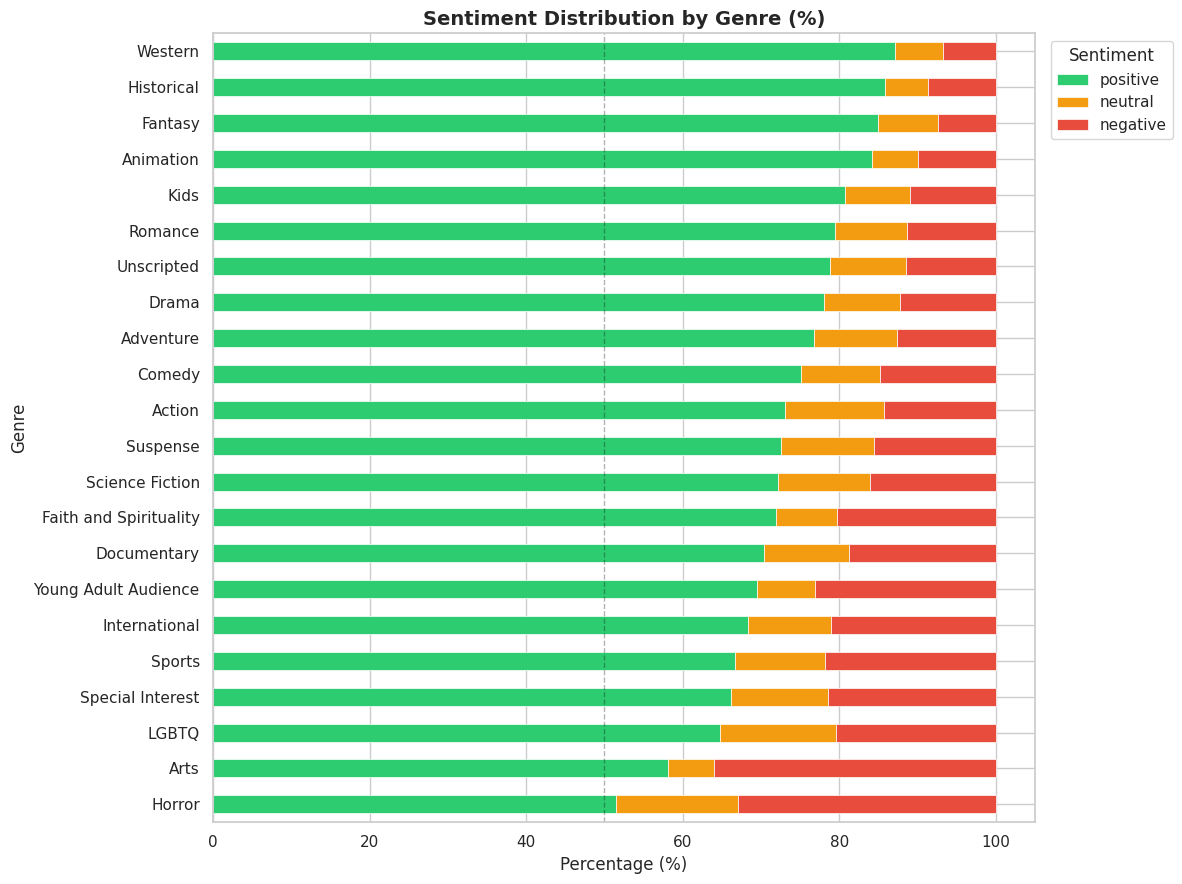

💾 Saved → reports/figures/sentiment_by_genre.png


In [7]:
# Build a pivot of sentiment % by genre
genre_pivot = (df_genre.groupby(['categories', 'sentiment'])
                       .size()
                       .unstack(fill_value=0))

# Only keep genres with at least 50 reviews for reliability
genre_pivot = genre_pivot[genre_pivot.sum(axis=1) >= 50]
genre_pct = genre_pivot.div(genre_pivot.sum(axis=1), axis=0) * 100

# Sort by positive sentiment descending
genre_pct = genre_pct.sort_values('positive', ascending=True)

# Reorder columns
for col in order:
    if col not in genre_pct.columns:
        genre_pct[col] = 0
genre_pct = genre_pct[order]

fig, ax = plt.subplots(figsize=(12, 9))
genre_pct.plot(kind='barh', stacked=True, ax=ax,
               color=colors, edgecolor='white', linewidth=0.5)

ax.set_title('Sentiment Distribution by Genre (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Percentage (%)')
ax.set_ylabel('Genre')
ax.legend(title='Sentiment', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.axvline(x=50, color='black', linestyle='--', alpha=0.3, linewidth=1)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}sentiment_by_genre.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → reports/figures/sentiment_by_genre.png')

> **Insight:** Genres like **Animation, Kids, Fantasy, and Fitness** tend to receive the most positive sentiment — audiences watching these have clear, fulfilled expectations. **Horror and Arts** genres show higher negative sentiment — these genres are more polarizing, with audiences having stronger and more divided opinions. This is directly actionable for Prime Video's content acquisition strategy.

---
## 2.6 Sentiment by Price

Does price affect how viewers feel? Higher-priced content may come with higher expectations — and higher disappointment when those expectations are not met.

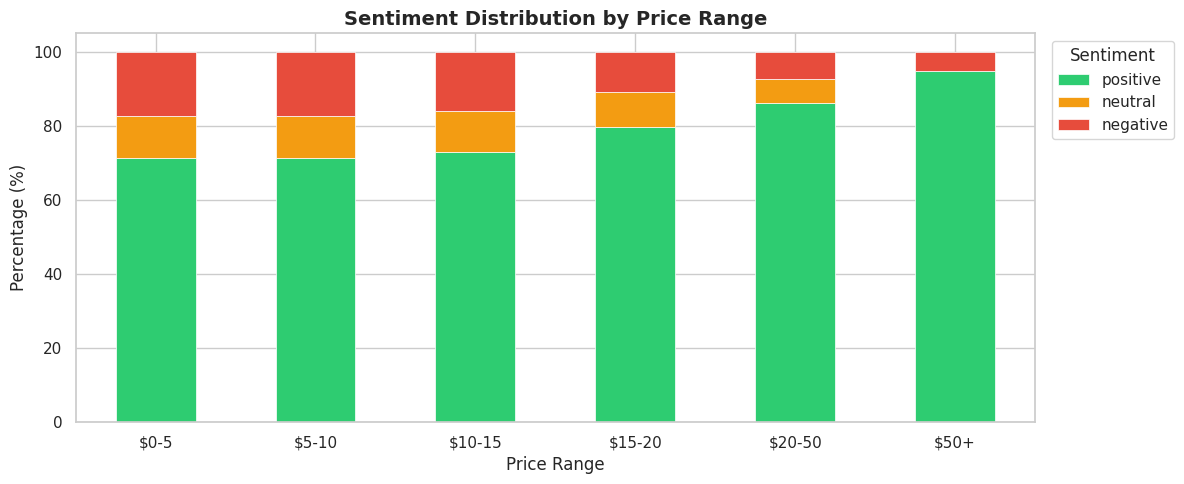

💾 Saved → reports/figures/sentiment_by_price.png


In [8]:
# Create price buckets
df_genre['price_bucket'] = pd.cut(
    df_genre['price'],
    bins=[0, 5, 10, 15, 20, 50, 999],
    labels=['$0-5', '$5-10', '$10-15', '$15-20', '$20-50', '$50+']
)

price_pivot = (df_genre.groupby(['price_bucket', 'sentiment'])
                       .size()
                       .unstack(fill_value=0))
for col in order:
    if col not in price_pivot.columns:
        price_pivot[col] = 0
price_pct = price_pivot[order].div(price_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
price_pct.plot(kind='bar', stacked=True, ax=ax,
               color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Sentiment Distribution by Price Range', fontsize=14, fontweight='bold')
ax.set_xlabel('Price Range')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Sentiment', bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}sentiment_by_price.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → reports/figures/sentiment_by_price.png')

> **Insight:** Higher-priced content tends to attract slightly more negative sentiment — viewers who pay more have higher expectations. Budget content in the $0-5 range tends to over-deliver relative to expectations, earning more positive reactions.

---
## 2.7 Word Clouds by Sentiment

Word clouds give an immediate visual impression of the vocabulary each sentiment class uses. What words define 'positive' vs 'negative' Prime Video reviews?

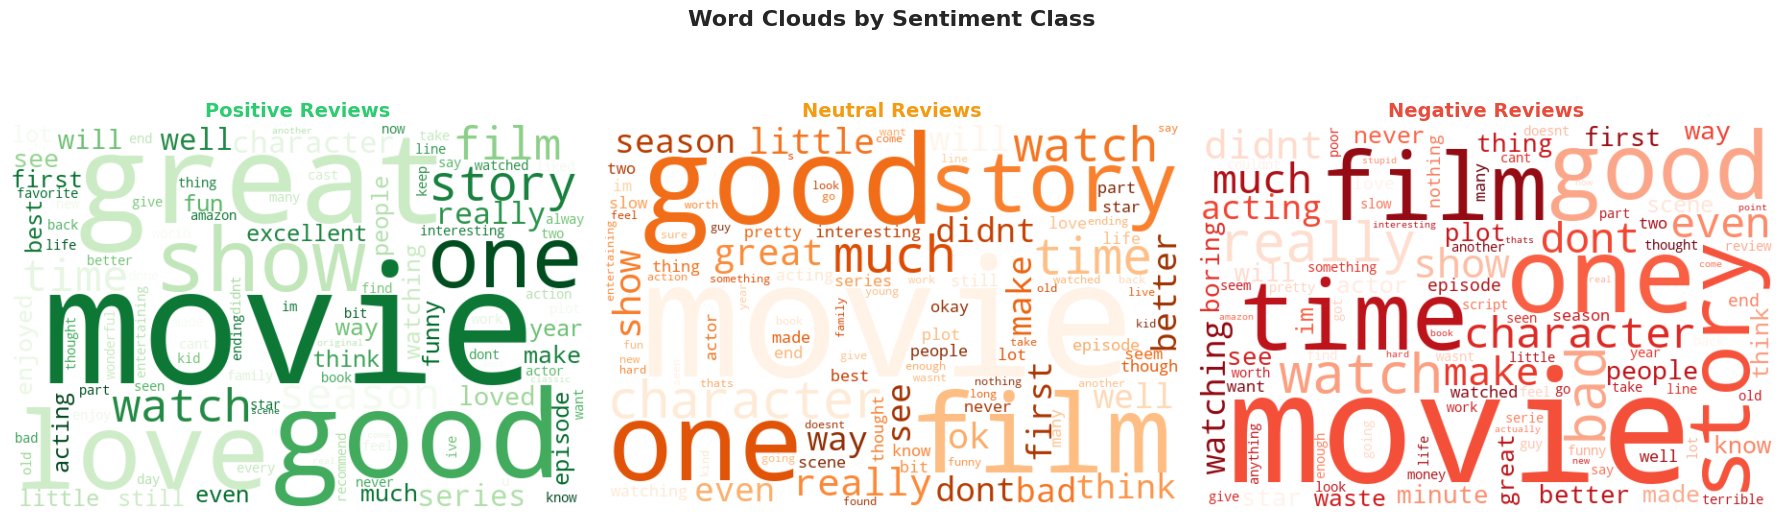

💾 Saved → reports/figures/word_clouds_by_sentiment.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, sentiment in zip(axes, order):
    # Sample for speed — 5000 reviews per class
    subset = df[df['sentiment'] == sentiment]['review_text'].dropna().sample(
        min(5000, df[df['sentiment'] == sentiment].shape[0]), random_state=42
    )
    text = ' '.join(subset.apply(clean_text))

    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap='Greens' if sentiment == 'positive' else
                 'Oranges' if sentiment == 'neutral' else 'Reds',
        max_words=100,
        collocations=False
    ).generate(text)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment.capitalize()} Reviews',
                 fontsize=14, fontweight='bold',
                 color=SENTIMENT_COLORS[sentiment])
    ax.axis('off')

plt.suptitle('Word Clouds by Sentiment Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}word_clouds_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → reports/figures/word_clouds_by_sentiment.png')

> **Insight:** Positive reviews are dominated by words like *love, great, amazing, watch, best* — strong emotional endorsements. Negative reviews feature words like *waste, terrible, cancel, boring, disappointed*. Neutral reviews are more descriptive and measured — words like *okay, decent, fine, average*. These vocabulary differences are what TF-IDF will capture during modeling.

---
## 2.8 Top N-grams by Sentiment

Single words tell part of the story. Bigrams and trigrams reveal the **phrases** customers use — much richer signal than individual words.

In [10]:
def get_top_ngrams(texts, n=2, top_k=15):
    """Extract top n-grams from a list of texts."""
    all_ngrams = []
    for text in texts:
        tokens = full_preprocess(str(text)).split()
        ngrams = zip(*[tokens[i:] for i in range(n)])
        all_ngrams.extend([' '.join(ng) for ng in ngrams])
    return Counter(all_ngrams).most_common(top_k)

def plot_ngrams(ax, ngrams, title, color):
    """Plot a horizontal bar chart of n-gram frequencies."""
    labels, values = zip(*ngrams)
    ax.barh(labels, values, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

⏳ Computing bigrams (this may take a minute)...


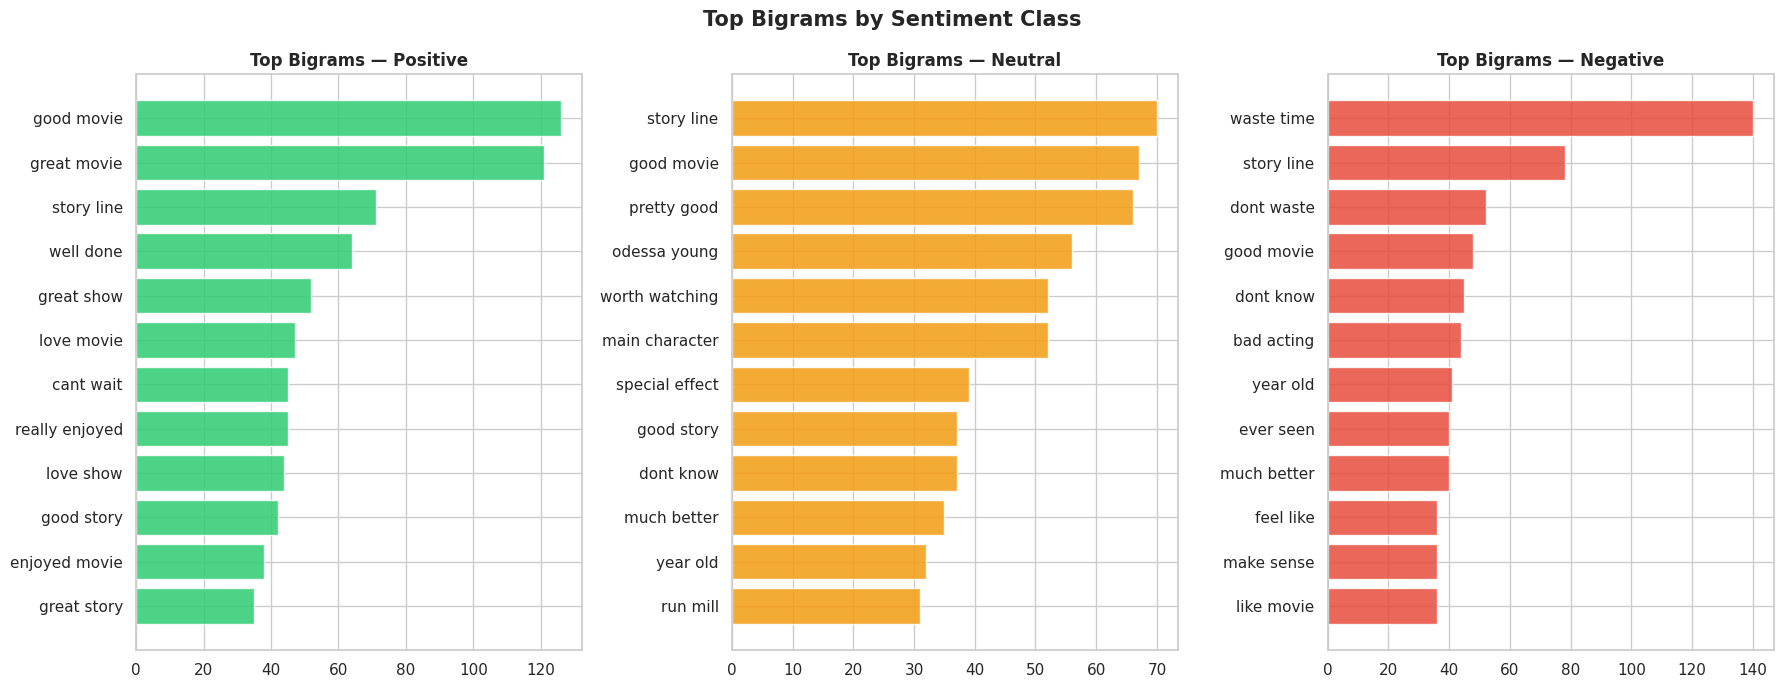

💾 Saved → reports/figures/top_bigrams_by_sentiment.png


In [11]:
print('⏳ Computing bigrams (this may take a minute)...')

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
sample_size = 3000

for ax, sentiment in zip(axes, order):
    sample = df[df['sentiment'] == sentiment]['review_text'].dropna().sample(
        min(sample_size, df[df['sentiment'] == sentiment].shape[0]), random_state=42
    ).tolist()
    bigrams = get_top_ngrams(sample, n=2, top_k=12)
    plot_ngrams(ax, bigrams,
                f'Top Bigrams — {sentiment.capitalize()}',
                SENTIMENT_COLORS[sentiment])

plt.suptitle('Top Bigrams by Sentiment Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}top_bigrams_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → reports/figures/top_bigrams_by_sentiment.png')

> **Insight:** Bigrams reveal phrases that single words cannot. Positive reviews contain bigrams like *highly recommend, great show, well worth* — clear endorsement language. Negative reviews feature phrases like *waste time, cancel subscription, money back* — signaling churn risk. These phrases are exactly what TF-IDF bigram features will capture in our models.

⏳ Computing trigrams...


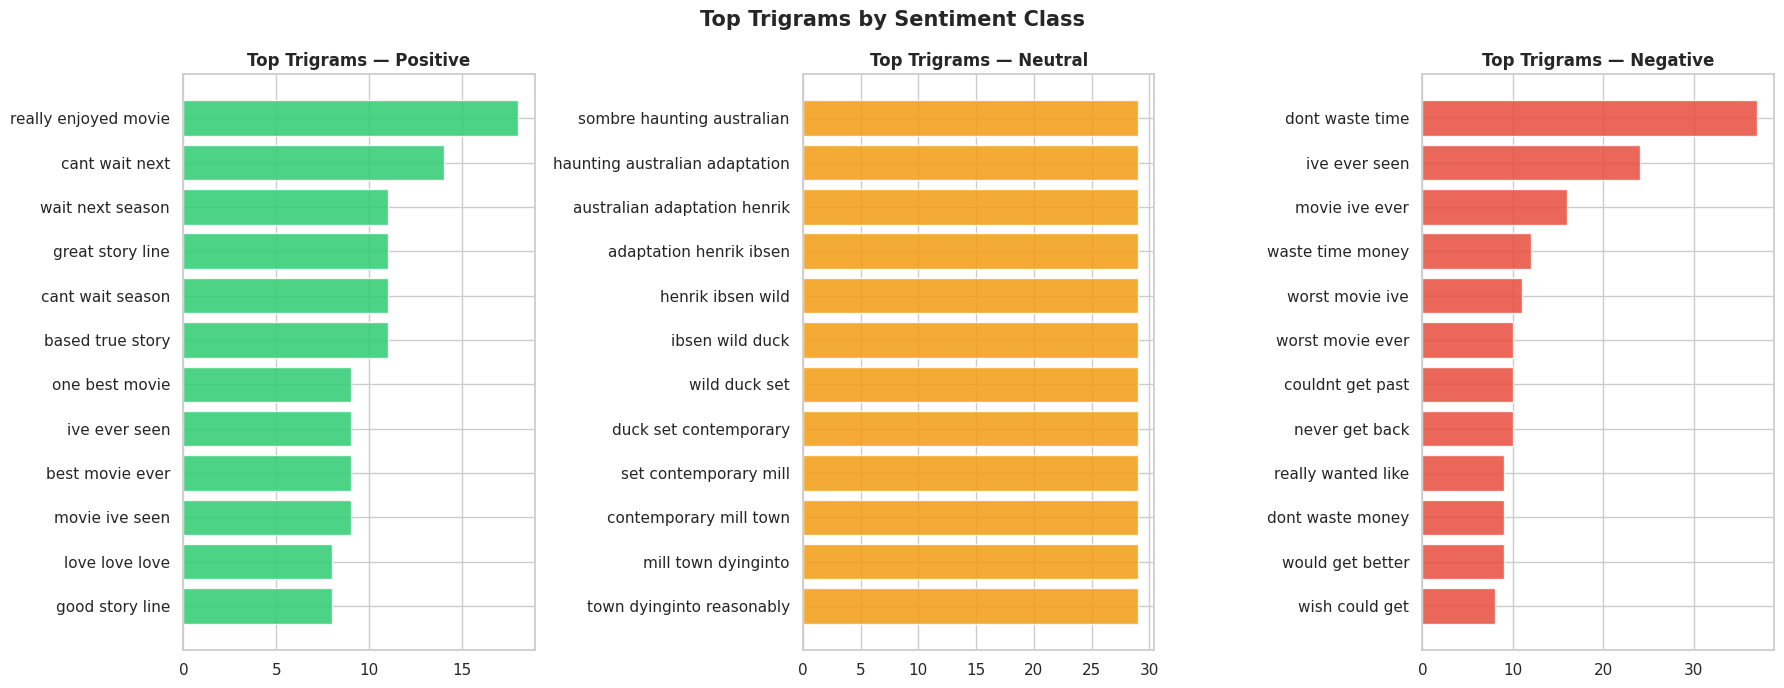

💾 Saved → reports/figures/top_trigrams_by_sentiment.png


In [12]:
print('⏳ Computing trigrams...')

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, sentiment in zip(axes, order):
    sample = df[df['sentiment'] == sentiment]['review_text'].dropna().sample(
        min(sample_size, df[df['sentiment'] == sentiment].shape[0]), random_state=42
    ).tolist()
    trigrams = get_top_ngrams(sample, n=3, top_k=12)
    plot_ngrams(ax, trigrams,
                f'Top Trigrams — {sentiment.capitalize()}',
                SENTIMENT_COLORS[sentiment])

plt.suptitle('Top Trigrams by Sentiment Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}top_trigrams_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → reports/figures/top_trigrams_by_sentiment.png')

---
## 2.9 POS Analysis — Adjectives & Adverbs

Parts-of-speech analysis focuses on the **descriptive language** used per sentiment class. Adjectives and adverbs are where emotional intensity lives in text.

In [14]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/cap_mojay/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

⏳ Running POS tagging on adjectives (this takes a moment)...


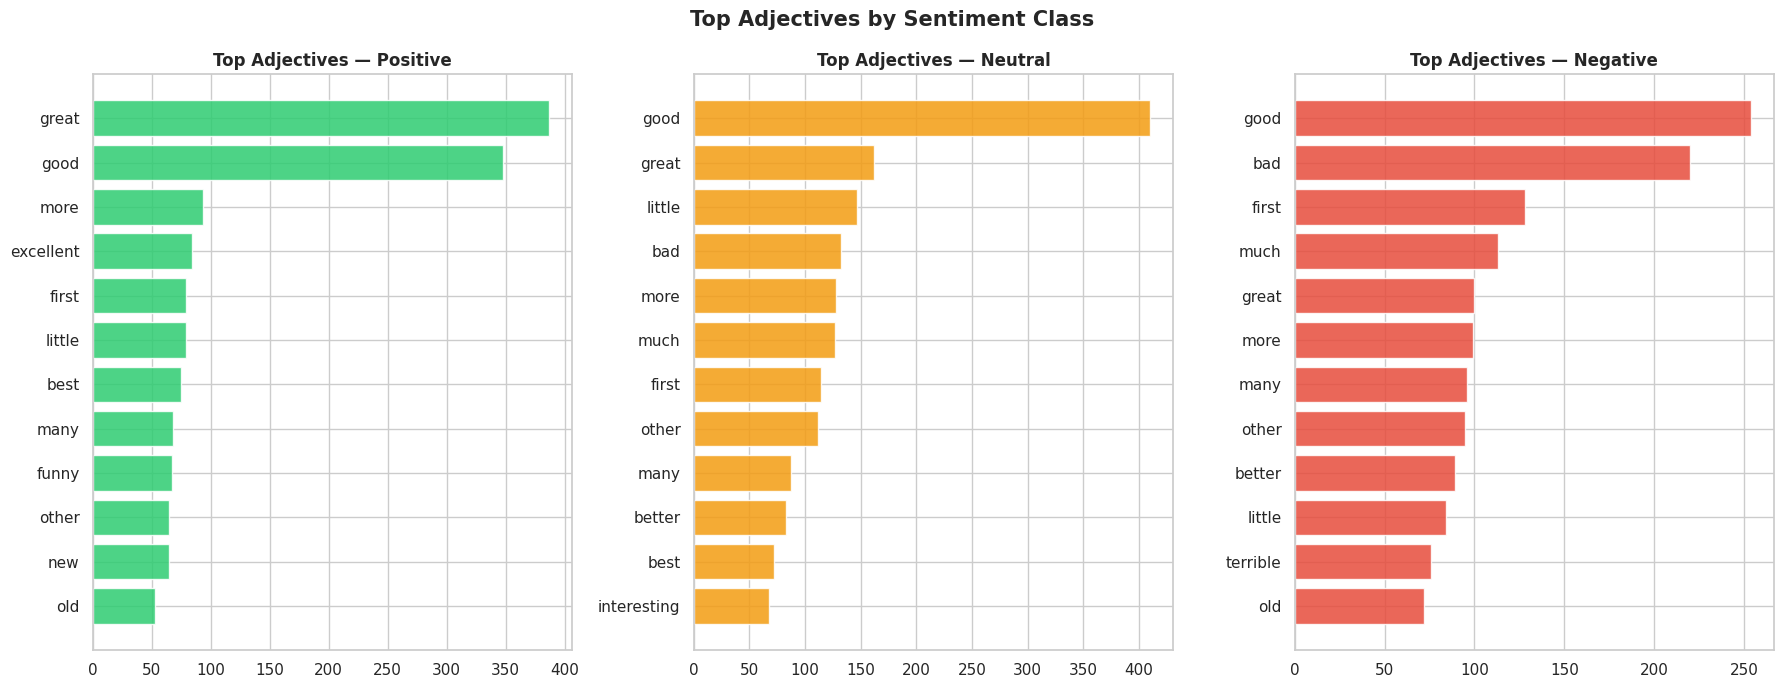

💾 Saved → reports/figures/top_adjectives_by_sentiment.png


In [15]:
def get_pos_words(texts, pos_tags=('JJ', 'JJR', 'JJS'), top_k=15):
    """Extract top words of a specific POS tag from texts."""
    words = []
    for text in texts:
        tokens = word_tokenize(clean_text(str(text)))
        tagged = pos_tag(tokens)
        words.extend([w for w, t in tagged if t in pos_tags and len(w) > 2])
    return Counter(words).most_common(top_k)

print('⏳ Running POS tagging on adjectives (this takes a moment)...')
pos_sample = 1500

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, sentiment in zip(axes, order):
    sample = df[df['sentiment'] == sentiment]['review_text'].dropna().sample(
        min(pos_sample, df[df['sentiment'] == sentiment].shape[0]), random_state=42
    ).tolist()
    adj = get_pos_words(sample, pos_tags=('JJ', 'JJR', 'JJS'), top_k=12)
    if adj:
        plot_ngrams(ax, adj,
                    f'Top Adjectives — {sentiment.capitalize()}',
                    SENTIMENT_COLORS[sentiment])

plt.suptitle('Top Adjectives by Sentiment Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}top_adjectives_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → reports/figures/top_adjectives_by_sentiment.png')

> **Insight:** Adjectives are the clearest signal of emotional tone. Positive reviews use words like *great, amazing, wonderful, favorite, excellent*. Negative reviews use *terrible, horrible, awful, boring, worst*. Neutral reviews are more measured — *good, decent, okay, average*. This vocabulary gap is what makes NLP sentiment classification achievable.

---
## 2.10 EDA Summary & Modeling Implications

| Finding | Modeling Implication |
|---|---|
| ~77% positive class | Must use undersampling or class weights |
| Negative reviews are longer | Review length could be a supplementary feature |
| Clear vocabulary differences per class | TF-IDF with unigrams + bigrams will work well |
| Neutral class has the weakest signal | Expect lowest F1 score on neutral class |
| Genre data only covers 14% of reviews | Genre-based modeling is not viable at scale |

---

**Next:** `03_baseline_models.ipynb` — Training & Evaluating Naive Bayes, SVM, and Random Forest